## Baseline Linear Regression model with 1-year lag

First I'll create the lag features

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

file_path = "../data/raw/Modified_Prov_Type_and_Round_Int_All_10_years.csv"

usecols = [
    "year",
    "Rndrng_NPI",                
    "Rndrng_Prvdr_Type",
    "Tot_Benes",
    "Tot_Srvcs",
    "Drug_Tot_Srvcs",
    "Bene_Avg_Risk_Scre",
    "Tot_Mdcr_Pymt_Amt"
]

df = pd.read_csv(file_path, usecols=usecols, low_memory=False)
df = df.sort_values(["Rndrng_NPI", "year"])


df["log_Tot_Benes"] = np.log1p(df["Tot_Benes"])
df["log_Tot_Srvcs"] = np.log1p(df["Tot_Srvcs"])

df["Srvcs_per_Bene"] = df["Tot_Srvcs"] / df["Tot_Benes"].replace(0, np.nan)
df["Srvcs_per_Bene"] = df["Srvcs_per_Bene"].fillna(0)

df["Drug_Srvcs_Share"] = df["Drug_Tot_Srvcs"] / df["Tot_Srvcs"].replace(0, np.nan)
df["Drug_Srvcs_Share"] = df["Drug_Srvcs_Share"].fillna(0)

df["log_Tot_Mdcr_Pymt_Amt"] = np.log1p(df["Tot_Mdcr_Pymt_Amt"])

# create 1-year lagged features by provider
group = df.groupby("Rndrng_NPI")

df["lag_Tot_Mdcr_Pymt_Amt"] = group["Tot_Mdcr_Pymt_Amt"].shift(1)
df["log_lag_payment"] = np.log1p(df["lag_Tot_Mdcr_Pymt_Amt"])

df["lag_log_Tot_Benes"] = group["log_Tot_Benes"].shift(1)
df["lag_log_Tot_Srvcs"] = group["log_Tot_Srvcs"].shift(1)
df["lag_Srvcs_per_Bene"] = group["Srvcs_per_Bene"].shift(1)
df["lag_Drug_Srvcs_Share"] = group["Drug_Srvcs_Share"].shift(1)
df["lag_Bene_Avg_Risk_Scre"] = group["Bene_Avg_Risk_Scre"].shift(1)

# drop rows missing any lagged predictors
df = df.dropna(subset=[
    "lag_Tot_Mdcr_Pymt_Amt",
    "lag_log_Tot_Benes",
    "lag_log_Tot_Srvcs",
    "lag_Srvcs_per_Bene",
    "lag_Drug_Srvcs_Share",
    "lag_Bene_Avg_Risk_Scre"
]).copy()



Note: Drug_Tot_Srvcs had ~10% missingness so I converted missing values to 0

In [80]:
corr = df["log_lag_payment"].corr(df["log_Tot_Mdcr_Pymt_Amt"])
print("Lag correlation:", corr) 

Lag correlation: 0.8970329160124345


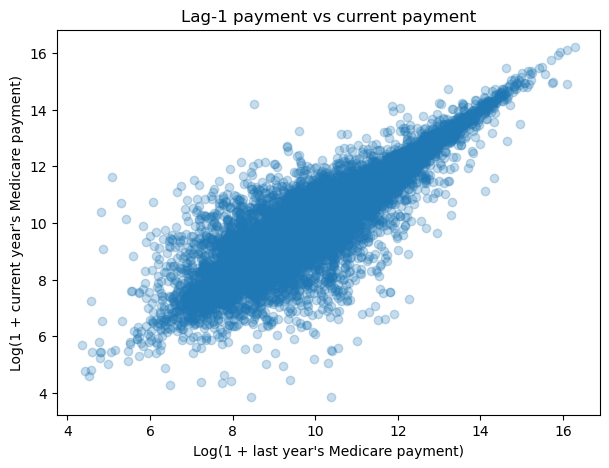

In [81]:
sample_df = df.sample(min(20000, len(df)), random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(
    sample_df["log_lag_payment"],
    sample_df["log_Tot_Mdcr_Pymt_Amt"],
    alpha=0.25
)
plt.xlabel("Log(1 + last year's Medicare payment)")
plt.ylabel("Log(1 + current year's Medicare payment)")
plt.title("Lag-1 payment vs current payment")
plt.show()

Now we must define our feature sets and do a Walk-forward evaluation loop

In [91]:
features_base = [
    "Rndrng_Prvdr_Type"
]

features_lag = [
    "Rndrng_Prvdr_Type",
    "log_lag_payment"
]

features_full = [
    "Rndrng_Prvdr_Type",
    "log_lag_payment",
    "lag_log_Tot_Benes",
    "lag_log_Tot_Srvcs",
    "lag_Srvcs_per_Bene",
    "lag_Drug_Srvcs_Share",
    "lag_Bene_Avg_Risk_Scre"
]

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error 

target = "log_Tot_Mdcr_Pymt_Amt"


def walk_forward_eval(df, features, model):

    results = []
    years = sorted(df["year"].unique())

    for test_year in years:
        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = pd.get_dummies(train[features], drop_first=True)
        X_test  = pd.get_dummies(test[features], drop_first=True)

        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        y_train = train[target]
        y_test  = test[target]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        log_ratio = preds - y_test
        mse=mean_squared_error(y_test, preds)
        rmse= np.sqrt(mse)
        r2= r2_score(y_test, preds)

        results.append({
            "year": test_year,
            "n_train": len(train),
            "n_test": len(test),
            "mean_log_ratio": log_ratio.mean(),
            "mean_abs_log_ratio": np.abs(log_ratio).mean(),
            "mse_log": mse,
            "rmse_log": rmse,
            "r2": r2
        })

    return pd.DataFrame(results)



In [92]:


all_features_for_comparison = list(set(features_base + features_lag + features_full))
comparison_df = df[["year", target] + all_features_for_comparison].dropna().copy() #this ensures all models have the same rows, same providers, and same years

from sklearn.linear_model import LinearRegression

base_results = walk_forward_eval(comparison_df, features_base, LinearRegression())
lag_results  = walk_forward_eval(comparison_df, features_lag, LinearRegression())
full_results = walk_forward_eval(comparison_df, features_full, LinearRegression())


comparison_table = pd.DataFrame({
    "Model": [
        "Provider Type",
        "Provider Type + Lag",
        "Full Features"
    ],
    
    "Mean Log Ratio": [
        base_results["mean_log_ratio"].mean(),
        lag_results["mean_log_ratio"].mean(),
        full_results["mean_log_ratio"].mean()
    ],
    
    "Mean Abs Log Ratio": [
        base_results["mean_abs_log_ratio"].mean(),
        lag_results["mean_abs_log_ratio"].mean(),
        full_results["mean_abs_log_ratio"].mean()
    ],
    
    "MSE (log)": [
        base_results["mse_log"].mean(),
        lag_results["mse_log"].mean(),
        full_results["mse_log"].mean()
    ],
    
    "RMSE (log)": [
        base_results["rmse_log"].mean(),
        lag_results["rmse_log"].mean(),
        full_results["rmse_log"].mean()
    ],
    
    "R²": [
        base_results["r2"].mean(),
        lag_results["r2"].mean(),
        full_results["r2"].mean()
    ]
})

comparison_table

comparison_table["Approx % Error"] = np.exp(comparison_table["Mean Abs Log Ratio"]) - 1
comparison_table = comparison_table.round(5)

comparison_table

,Model,Mean Log Ratio,Mean Abs Log Ratio,MSE (log),RMSE (log),R²,Approx % Error
0,Provider Type,0.01816,0.99672,1.73983,1.31901,0.21073,1.70937
1,Provider Type + Lag,0.01886,0.40828,0.43218,0.65681,0.80375,0.50423
2,Full Features,0.02238,0.40837,0.43079,0.65576,0.80438,0.50437


In [85]:
lr_results = walk_forward_eval(comparison_df, features_full, LinearRegression())

This comparison table shows that provider type alone is a weak predictor with high error and adding lag improved performance greatly. Lagged Medicare payments are the primary driver of future spending, while additional provider-level features provide limited incremental predictive power in a linear modeling framework.

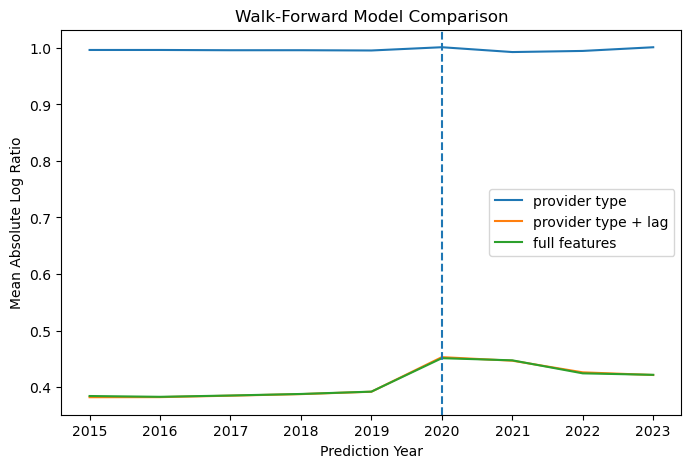

In [93]:
plt.figure(figsize=(8,5))

plt.plot(base_results["year"], base_results["mean_abs_log_ratio"], label="provider type")
plt.plot(lag_results["year"], lag_results["mean_abs_log_ratio"], label="provider type + lag")
plt.plot(full_results["year"], full_results["mean_abs_log_ratio"], label="full features")

plt.ylabel("Mean Absolute Log Ratio")
plt.xlabel("Prediction Year")
plt.axvline(x=2020, linestyle="--")
plt.legend()
plt.title("Walk-Forward Model Comparison")

plt.show()

In [76]:
df.groupby("year")["Tot_Mdcr_Pymt_Amt"].mean()

year
2014    99619.227467
2015    98603.018602
2016    97192.279791
2017    95904.176889
2018    96052.388582
2019    97322.704236
2020    88342.709471
2021    96746.604740
2022    92003.736344
2023    94478.060949
Name: Tot_Mdcr_Pymt_Amt, dtype: float64

The increase in prediction error during 2020–2021 coincides with the COVID-19 pandemic, which significantly disrupted healthcare utilization patterns. Because the model relies heavily on lagged spending and historical trends, these disruptions likely reduced predictive accuracy during those years.

In [101]:
def get_predictions(df, features, model):

    years = sorted(df["year"].unique())
    preds_list = []

    for test_year in years:
        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = pd.get_dummies(train[features], drop_first=True)
        X_test  = pd.get_dummies(test[features], drop_first=True)

        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        y_train = train[target]
        y_test  = test[target]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        temp = pd.DataFrame({
            "actual_log": y_test,
            "pred_log": preds
        })

        preds_list.append(temp)

    return pd.concat(preds_list)

pred_df = get_predictions(
    comparison_df,
    features_full,
    LinearRegression()
)

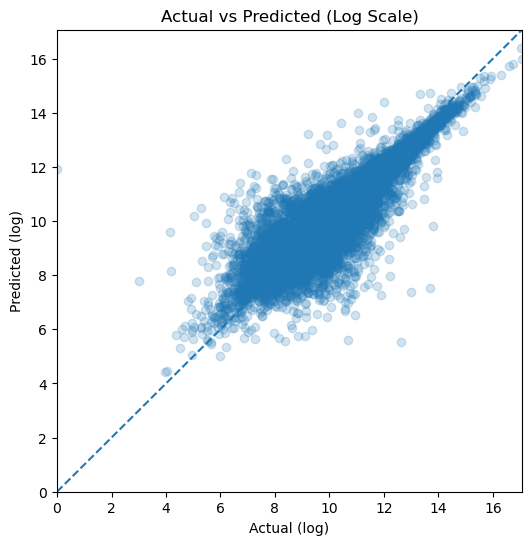

In [108]:
plot_df = pred_df.sample(min(20000, len(pred_df)), random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(plot_df["actual_log"], plot_df["pred_log"], alpha=0.2)

lims = [
    min(plot_df["actual_log"].min(), plot_df["pred_log"].min()),
    max(plot_df["actual_log"].max(), plot_df["pred_log"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual (log)")
plt.ylabel("Predicted (log)")
plt.title("Actual vs Predicted (Log Scale)")
plt.show()

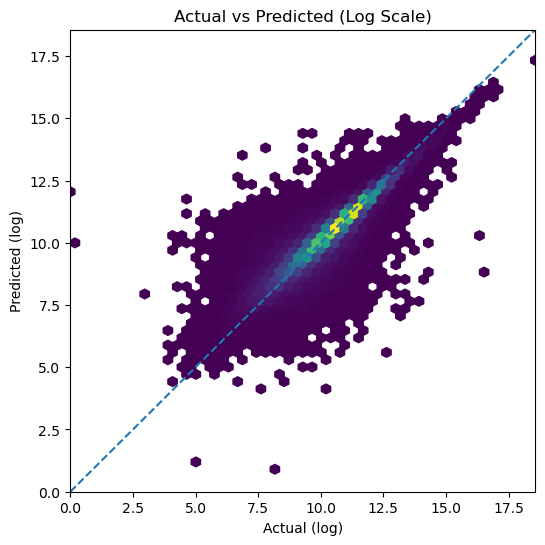

In [109]:
plot_df = pred_df.sample(min(100000, len(pred_df)), random_state=42)

plt.figure(figsize=(6,6))
plt.hexbin(plot_df["actual_log"], plot_df["pred_log"], gridsize=50, mincnt=1)

lims = [
    min(plot_df["actual_log"].min(), plot_df["pred_log"].min()),
    max(plot_df["actual_log"].max(), plot_df["pred_log"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual (log)")
plt.ylabel("Predicted (log)")
plt.title("Actual vs Predicted (Log Scale)")
plt.show()

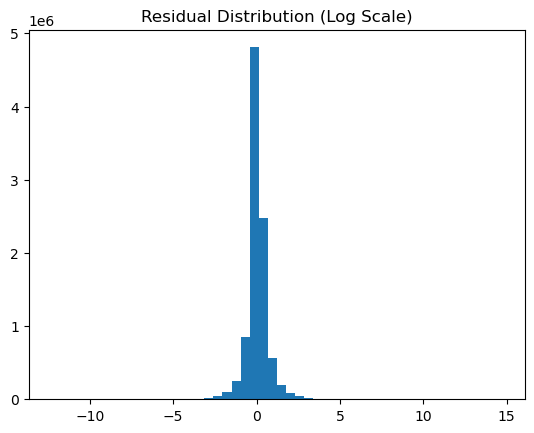

In [103]:
pred_df["residual"] = pred_df["pred_log"] - pred_df["actual_log"]

plt.hist(pred_df["residual"], bins=50)
plt.title("Residual Distribution (Log Scale)")
plt.show()

## Next Steps: 
I will attempt to add a Random Forest model to capture the nonlinear relationship between our features.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def walk_forward_eval(df, features, model):

    results = []
    years = sorted(df["year"].unique())

    for test_year in years:

        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = pd.get_dummies(train[features], drop_first=True)
        X_test  = pd.get_dummies(test[features], drop_first=True)

        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        y_train = train[target]
        y_test  = test[target]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        log_ratio = preds - y_test
        

        results.append({
            "year": test_year,
            "n_train": len(train),
            "n_test": len(test),
            "metric_mean": log_ratio.mean(),
            "metric_abs": np.abs(log_ratio).mean()
        })

    return pd.DataFrame(results)

In [87]:
rf_df = comparison_df.sample(300000, random_state=42).copy()

In [89]:
from sklearn.linear_model import LinearRegression

lr_results = walk_forward_eval(
    comparison_df,
    features_full,
    LinearRegression()
)

from sklearn.ensemble import RandomForestRegressor

rf_results = walk_forward_eval(
    rf_df,
    features_full,
    RandomForestRegressor(
        n_estimators=30,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    )
)

In [94]:
lr_results

,year,n_train,n_test,metric_mean,metric_abs
0,2015,895535,933669,-0.002538,0.384093
1,2016,1829204,969933,0.021759,0.382677
2,2017,2799137,1005533,0.025349,0.384989
3,2018,3804670,1038219,0.013224,0.387713
4,2019,4842889,1069792,-0.001784,0.391833
5,2020,5912681,1082567,0.179641,0.451028
6,2021,6995248,1107248,-0.129544,0.447230
7,2022,8102496,1136672,0.067292,0.424191
8,2023,9239168,1167621,0.028012,0.421598


In [88]:
rf_results

,year,n_train,n_test,metric_mean,metric_abs
0,2015,26065,26987,-0.009010,0.256213
1,2016,53052,28082,0.010100,0.246040
2,2017,81134,29013,0.008616,0.246047
3,2018,110147,29685,-0.002209,0.245672
4,2019,139832,30688,-0.017142,0.248560
5,2020,170520,31235,0.067289,0.278590
6,2021,201755,31823,-0.123776,0.278679
7,2022,233578,32788,-0.005617,0.261052
8,2023,266366,33634,-0.028738,0.255637


In [95]:
model_comparison = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest"],
    "mean_abs_log_ratio": [
        lr_results["metric_abs"].mean(),
        rf_results["metric_abs"].mean()
    ]
})

model_comparison

,model,mean_abs_log_ratio
0,Linear Regression,0.408373
1,Random Forest,0.402460


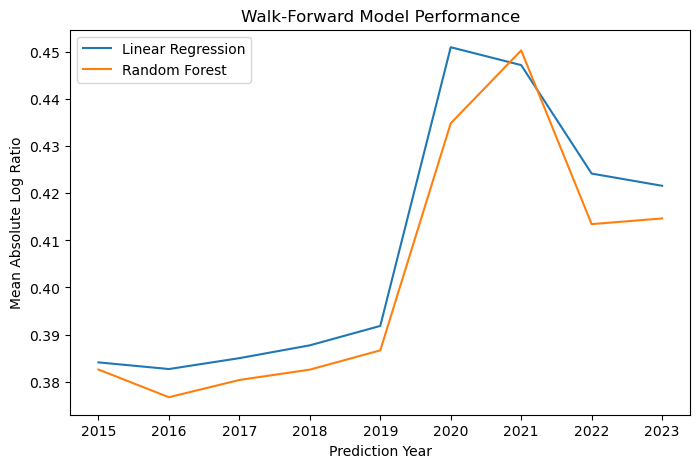

In [96]:
plt.figure(figsize=(8,5))

plt.plot(lr_results["year"], lr_results["metric_abs"], label="Linear Regression")
plt.plot(rf_results["year"], rf_results["metric_abs"], label="Random Forest")

plt.xlabel("Prediction Year")
plt.ylabel("Mean Absolute Log Ratio")
plt.title("Walk-Forward Model Performance")

plt.legend()
plt.show()

Random forest could be usefull for capturing the nonlinear relationships, the mean absolute log ratio improved. However there is still concern fot overfitting temporal patterns simliar to the linear regression model.